# Peramalan Kadar Nitrogen Dioksida ($NO_2$) Harian di Kabupaten Pamekasan Menggunakan K-Nearest Neighbor Regression

## Deskripsi Proyek

Proyek ini membahas proses peramalan kadar Nitrogen Dioksida (NO₂) harian di Kabupaten Pamekasan, Madura menggunakan algoritma K-Nearest Neighbor (KNN) Regression. Data diperoleh dari satelit Sentinel-5P melalui platform Copernicus Data Space Ecosystem dengan rentang waktu 1 Oktober 2023 hingga 30 September 2025.

Tahapan penelitian meliputi pengumpulan data, preprocessing data, penanganan missing value menggunakan Interpolasi Linear, deteksi dan penanganan outlier menggunakan metode Interquartile Range (IQR), normalisasi data menggunakan Min-Max Scaling, pembentukan data time series menjadi format supervised learning, serta pemodelan menggunakan KNN Regression dengan beberapa skenario lag (4 hari, 10 hari, dan 30 hari sebelumnya).

Evaluasi model dilakukan menggunakan metrik Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), dan Coefficient of Determination (R² Score) untuk mengetahui performa model dalam memprediksi kadar NO₂ harian di Kabupaten Pamekasan.

# 1. Pengumpulan Data

Pada penelitian ini dilakukan pengumpulan data time series harian kadar Nitrogen Dioksida (NO₂) di Kabupaten Pamekasan, Madura. Data diperoleh dari platform Copernicus Data Space Ecosystem yang menyediakan berbagai data pengamatan bumi dari satelit Sentinel, termasuk data kualitas udara Sentinel-5P.

Sebelum melakukan pengambilan data, pengguna harus membuat akun terlebih dahulu pada platform Copernicus Data Space melalui situs:

https://dataspace.copernicus.eu/

Dokumentasi resmi mengenai pengambilan data NO₂ dapat diakses pada halaman berikut:

https://documentation.dataspace.copernicus.eu/notebook-samples/openeo/NO2Covid.html

Pada penelitian ini, proses pengambilan data dilakukan menggunakan Google Colaboratory (Google Colab) dengan bahasa pemrograman Python. Oleh karena itu, tidak diperlukan penggunaan layanan JupyterLab yang disediakan oleh Copernicus Data Space.

Data yang diambil merupakan data kadar NO₂ harian pada wilayah Kabupaten Pamekasan dengan rentang waktu pengamatan mulai 1 Oktober 2023 hingga 30 September 2025. Wilayah pengamatan ditentukan menggunakan koordinat Area of Interest (AOI) yang merepresentasikan Kabupaten Pamekasan.

Sebelum melakukan proses pengambilan data, terlebih dahulu dilakukan instalasi pustaka OpenEO menggunakan perintah berikut:

In [57]:
pip install openeo

Selanjutnya dilakukan proses autentikasi ke server Copernicus Data Space menggunakan kode Python berikut:

In [58]:
import openeo

In [59]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


Saat kode dijalankan, sistem akan menghasilkan tautan autentikasi yang harus dibuka menggunakan browser. Pengguna kemudian melakukan login menggunakan akun Copernicus Data Space yang telah dibuat sebelumnya. Setelah proses autentikasi berhasil, data Sentinel-5P dapat diakses dan digunakan untuk proses pengambilan data kadar $NO_2$.

In [60]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [113.43829940226072, -6.905966819583142],
            [113.56286672992422, -6.906009779247256],
            [113.56288473222185, -7.120424658159095],
            [113.43829951152071, -7.1204262101393],
            [113.43829940226072, -6.905966819583142],
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2023-10-01", "2025-10-01"],
    spatial_extent={
        "west": 113.43829940226072,
        "south": -7.1204262101393,
        "east": 113.56288473222185,
        "north": -6.905966819583142
    },
    bands=["NO2"],
)

# Now aggregate by day to avoid having multiple data per day
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Now create a spatial aggregation to generate mean timeseries data
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

Code di atas memerlukan koordinat wilayah yang akan dijadikan area pengambilan data. Untuk memperoleh koordinat tersebut, kunjungi:

https://geojson.io/?map=8.89/-7.04/113.48#map=14.8/-7.04732/112.69463

Pada halaman tersebut, gunakan fitur **Draw Rectangle** atau **Draw Polygon** untuk menandai wilayah yang ingin dianalisis, misalnya Kabupaten Pamekasan. Setelah area dipilih, koordinat akan otomatis muncul dalam format **GeoJSON** pada panel sebelah kanan.

Salin koordinat tersebut kemudian sesuaikan pada variabel `aoi` dan `spatial_extent` pada kode Python. Koordinat ini digunakan untuk menentukan batas wilayah yang akan diambil data konsentrasi NO₂ dari satelit Sentinel-5P.

![image](https://hackmd.io/_uploads/ry_92XTefx.png)



Pada panel sebelah kanan akan ditampilkan data koordinat wilayah dalam format GeoJSON berdasarkan area yang telah dipilih. Salin koordinat tersebut, kemudian sesuaikan pada bagian variabel `aoi` dan `spatial_extent` pada kode Python yang digunakan untuk mengambil data.

Setelah koordinat wilayah berhasil ditentukan, tambahkan kode berikut untuk memulai proses pengambilan data:

In [61]:
job = s5post.execute_batch(title="NO2 in Pamekasan", outputfile="NO2Pamekasan.nc")

0:00:00 Job 'j-26060309005545cd98726b1a76ab3004': send 'start'
0:00:05 Job 'j-26060309005545cd98726b1a76ab3004': queued (progress 0%)
0:00:10 Job 'j-26060309005545cd98726b1a76ab3004': queued (progress 0%)
0:00:17 Job 'j-26060309005545cd98726b1a76ab3004': queued (progress 0%)
0:00:25 Job 'j-26060309005545cd98726b1a76ab3004': queued (progress 0%)
0:00:35 Job 'j-26060309005545cd98726b1a76ab3004': queued (progress 0%)
0:00:47 Job 'j-26060309005545cd98726b1a76ab3004': queued (progress 0%)
0:01:03 Job 'j-26060309005545cd98726b1a76ab3004': queued (progress 0%)
0:01:22 Job 'j-26060309005545cd98726b1a76ab3004': queued (progress 0%)
0:01:47 Job 'j-26060309005545cd98726b1a76ab3004': running (progress N/A)
0:02:17 Job 'j-26060309005545cd98726b1a76ab3004': running (progress N/A)
0:02:54 Job 'j-26060309005545cd98726b1a76ab3004': running (progress N/A)
0:03:41 Job 'j-26060309005545cd98726b1a76ab3004': running (progress N/A)
0:04:40 Job 'j-26060309005545cd98726b1a76ab3004': running (progress N/A)
0:05

Status `N/A` yang muncul pada proses running dapat diabaikan karena hanya menunjukkan bahwa persentase progres tidak dapat ditampilkan oleh server pada saat itu. Selama status job masih berada pada kondisi `running`, proses pengolahan data tetap berjalan normal.

Selain melalui terminal, proses pengambilan data juga dapat dipantau melalui halaman OpenEO Editor:

https://editor.openeo.org/?server=https%3A%2F%2Fopeneo.dataspace.copernicus.eu%2Fopeneo%2F1.2

Pada halaman tersebut akan ditampilkan daftar job yang pernah dijalankan, termasuk nama dataset, status proses, waktu eksekusi, serta file hasil yang dapat diunduh setelah proses selesai. Dengan demikian, pengguna dapat memantau perkembangan pengambilan data secara langsung hingga status berubah menjadi `finished`.

![image](https://hackmd.io/_uploads/Skvg6Q6xzg.png)

# 2. Preproccessing Data

Setelah proses pengambilan data selesai, file hasil akan tersimpan dalam format **NetCDF (.nc)** dengan nama `NO2Pamekasan.nc`. Pada penelitian ini, proses pengambilan dan pengolahan data dilakukan menggunakan Google Colab sehingga file hasil dapat langsung digunakan untuk tahap selanjutnya tanpa perlu mengunduhnya secara manual.

Sebelum membaca file NetCDF, terlebih dahulu dilakukan instalasi library **netCDF4** menggunakan perintah berikut:


In [62]:
!pip install -q netCDF4

Untuk membaca file NetCDF dan mengekstrak data yang diperlukan, digunakan library `netCDF4` dengan kode berikut:


In [63]:
import netCDF4

file_path = "NO2Pamekasan.nc"
ds = netCDF4.Dataset(file_path)

# Lihat seluruh variabel yang tersedia
print("📦 Variabel dalam file:")
print(ds.variables.keys())
# dict_keys(['t', 'x', 'y', 'crs', 'NO2'])

# Ambil NO2
no2 = ds.variables["NO2"][:]

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal jika punya atribut 'units'
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback kalau tidak ada units

# Tampilkan struktur data NO2
print(type(no2))
# type <class 'numpy.ma.core.MaskedArray'>

print(len(no2))
# banyaknya data record NO2 725

print(len(no2[0]))
# panjang data perbaris 9

print(len(no2[0][0]))
# panjang perdata 8

print(no2[0][0][0])
# 3.7701793e-05

📦 Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])
<class 'numpy.ma.MaskedArray'>
724
7
3
3.3967026e-05


Dari kode di atas, kita dapat mengetahui struktur data pada variabel `NO2`. Hasil pengecekan menunjukkan bahwa data NO₂ memiliki bentuk tiga dimensi yang terdiri dari dimensi waktu (*time*), baris (*y*), dan kolom (*x*). Setiap record harian berisi beberapa nilai NO₂ yang mewakili grid pengamatan pada wilayah Pamekasan.

Struktur data NO₂ untuk setiap record dapat digambarkan sebagai berikut:

```
[
    [[] * 8] * 9
]
```

Artinya, setiap tanggal memiliki data NO₂ yang tersusun dalam matriks berukuran 9 × 8. Untuk melihat isi data pada beberapa record pertama, gunakan kode berikut:

In [64]:
print("Contoh data pertama:")
for i in range(0, 10):
    print(no2[i])

Contoh data pertama:
[[3.39670259563718e-05 2.1042213120381348e-05 1.683634218352381e-05]
 [3.39670259563718e-05 1.5583350432279985e-06 1.7716231013764627e-05]
 [8.58146358950762e-06 1.5583350432279985e-06 2.3610215066582896e-05]
 [1.583823723194655e-05 1.5011952200438827e-05 2.3610215066582896e-05]
 [1.583823723194655e-05 3.4694685382419266e-06 2.0833485905313864e-05]
 [2.0854138711001724e-05 3.4694685382419266e-06 1.777386205503717e-05]
 [2.1272702724672854e-05 1.9406050341785885e-05 1.777386205503717e-05]]
[[1.1449212252045982e-05 1.1449212252045982e-05 1.1233086297579575e-05]
 [1.1449212252045982e-05 1.4201823432813399e-05 1.7122372810263187e-05]
 [1.4201823432813399e-05 1.4201823432813399e-05 1.5042684935906436e-05]
 [4.070420800417196e-06 4.070420800417196e-06 1.5042684935906436e-05]
 [4.070420800417196e-06 2.2656678993371315e-05 1.8827575331670232e-05]
 [2.2656678993371315e-05 2.2656678993371315e-05 7.4363920248288196e-06]
 [1.7138083421741612e-05 1.7138083421741612e-05 7.436392

Karena dalam satu hari terdapat banyak nilai $NO_2$, maka nilai tersebut akan dirata-ratakan sehingga setiap tanggal hanya memiliki satu nilai $NO_2$. Namun, pada data ditemukan beberapa missing value yang ditandai dengan simbol `--`, seperti pada contoh ouput terminal di atas.

## a. Mengatasi Missing Value Menggunakan Metode Interpolasi Linear

Selanjutnya, kita akan mengatasi permasalahan *missing value* pada data NO₂ menggunakan metode **Interpolasi Linear**. Metode ini mengisi nilai yang hilang berdasarkan pola nilai sebelum dan sesudahnya sehingga data menjadi lebih lengkap dan dapat digunakan pada tahap analisis berikutnya.

In [65]:
import numpy as np
import pandas as pd

# Interpolasi Linear
no2_filled = np.zeros_like(no2)
# Untuk jaga-jaga jika terdapat '--' tidak berubah menjadi 0
no2_filled = no2_filled.filled(0)

# loop tiap grid (y,x)
for i in range(no2.shape[1]):     # 9 baris
    for j in range(no2.shape[2]): # 8 kolom
        series = pd.Series(no2[:, i, j])
        no2_filled[:, i, j] = series.interpolate(method='linear', limit_direction='both').to_numpy()

Dengan kode di atas, seluruh missing value pada data $NO_2$ akan terisi secara otomatis menggunakan metode Interpolasi Linear.

## b. Merata-ratakan Data dan Mengubah Format Datetime

Setelah missing value berhasil diatasi, langkah berikutnya adalah menghitung rata-rata nilai NO₂ pada setiap tanggal sehingga setiap record hanya memiliki satu nilai NO₂. Pada tahap ini, format tanggal juga diubah dari `YYYY-MM-DD HH:MM:SS` menjadi `YYYY-MM-DD` karena penelitian menggunakan data time series harian.

In [66]:
new_dates = []
new_no2 = []
for i in range(len(dates)):
    # ubah format datetime
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2_filled[i]))

## c. Menyimpan Data ke Format CSV

Setelah proses perataan selesai, data disimpan dalam bentuk DataFrame Pandas dan diekspor ke format CSV agar lebih mudah digunakan pada tahap preprocessing dan pemodelan.

In [67]:
df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

# Simpan ke CSV
df.to_csv("NO2_Pamekasan_timeseries.csv", index=False)

print(df.head())

         date       NO2
0  2023-10-01  0.000017
1  2023-10-02  0.000014
2  2023-10-03  0.000009
3  2023-10-04  0.000008
4  2023-10-05  0.000013


Dengan langkah tersebut, data $NO_2$ harian berhasil dibersihkan, dirata-ratakan, dan disimpan ke dalam file CSV untuk digunakan pada proses selanjutnya.

## d. Pengecekan Missing Value Data Harian pada CSV

Setelah data disimpan dalam format CSV, langkah berikutnya adalah memeriksa apakah data time series harian sudah lengkap atau masih terdapat tanggal yang hilang. Pengecekan dilakukan dengan membandingkan tanggal pada dataset dengan rentang tanggal yang seharusnya tersedia.


In [68]:
import pandas as pd
import numpy as np

df = pd.read_csv("NO2_Pamekasan_timeseries.csv")

# Pastikan kolom 'date' bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2023-10-01"
end_date = "2025-09-30"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 7
Daftar tanggal missing:
DatetimeIndex(['2023-11-11', '2024-01-01', '2024-03-11', '2024-03-23',
               '2024-08-12', '2025-01-30', '2025-01-31'],
              dtype='datetime64[ns]', freq=None)


Hasil pengecekan menunjukkan bahwa masih terdapat beberapa tanggal yang hilang (missing date). Oleh karena itu, dilakukan kembali proses Interpolasi Linear untuk melengkapi data harian yang belum tersedia.

In [69]:
import pandas as pd

# Pastikan datetime dan sorting
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Buat rentang tanggal lengkap
full_range = pd.date_range(start="2023-10-01", end="2025-09-30", freq='D')

# Reindex agar tanggal yang hilang muncul sebagai NaN
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

# Interpolasi linear berdasarkan indeks waktu
df['NO2'] = df['NO2'].interpolate(method='time')

# (Opsional) jika masih ada NaN di bagian awal/akhir bisa gunakan forward/backward fill
df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')

# Simpan kembali ke CSV
df.to_csv("no2_timeseries_interpolated.csv")

/tmp/ipykernel_1307/2413223189.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')


Setelah proses interpolasi dilakukan, seluruh tanggal pada rentang pengamatan telah tersedia sehingga tidak terdapat lagi missing value harian pada dataset.

In [70]:
import pandas as pd
import numpy as np

df = pd.read_csv("no2_timeseries_interpolated.csv")

# Pastikan kolom 'date' bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2023-10-01"
end_date = "2025-09-30"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 0
Daftar tanggal missing:
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


Kode di atas digunakan untuk memastikan bahwa data time series harian sudah lengkap dan tidak terdapat tanggal yang hilang. Pertama, data hasil interpolasi dibaca dari file `no2_timeseries_interpolated.csv`, kemudian kolom `date` diubah ke format datetime.

Selanjutnya dibuat rentang tanggal lengkap dari 1 Oktober 2023 hingga 30 September 2025 menggunakan `pd.date_range()`. Rentang tanggal tersebut dibandingkan dengan tanggal yang ada pada dataset menggunakan fungsi `difference()`. Hasil perbandingan akan menampilkan jumlah dan daftar tanggal yang masih hilang pada data.

Apabila output menunjukkan:

```
Jumlah hari missing: 0
Daftar tanggal missing:
DatetimeIndex([], dtype='datetime64[ns]', freq='D')
```

maka dapat disimpulkan bahwa seluruh tanggal pada rentang pengamatan telah tersedia dan tidak terdapat missing value harian pada dataset.

## e. Deteksi Outlier Menggunakan Metode IQR

Setelah seluruh missing value berhasil diatasi menggunakan Interpolasi Linear, langkah berikutnya adalah mendeteksi data outlier menggunakan metode Interquartile Range (IQR). Metode ini digunakan untuk mengidentifikasi nilai yang berada jauh di luar rentang data normal.

Kode berikut digunakan untuk menghitung batas bawah (lower bound) dan batas atas (upper bound) berdasarkan nilai kuartil pertama (Q1) dan kuartil ketiga (Q3), kemudian menampilkan data yang terdeteksi sebagai outlier.

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("no2_timeseries_interpolated.csv")

df['date'] = pd.to_datetime(df['date'])

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())

Jumlah Outlier (IQR): 8
         date       NO2
25 2023-10-26  0.000026
38 2023-11-08  0.000027
39 2023-11-09  0.000029
40 2023-11-10  0.000028
41 2023-11-11  0.000027


Hasil deteksi menunjukkan terdapat 8 data outlier pada data time series $NO_2$.

Untuk mempermudah identifikasi outlier, data divisualisasikan menggunakan grafik garis dan titik outlier ditandai dengan warna merah.

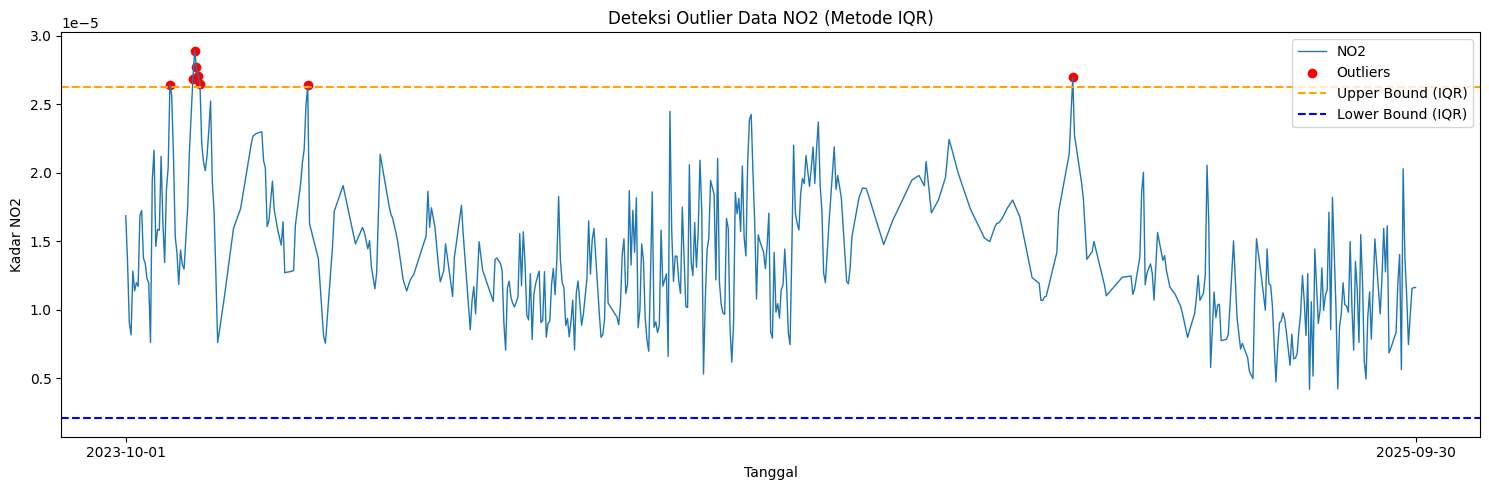

In [72]:
# === Visualisasi ===
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

# Titik Outlier
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

# Garis batas atas & bawah
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue', linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Gambar X. Visualisasi hasil deteksi outlier menggunakan metode IQR.

Karena data yang digunakan merupakan data time series, outlier tidak langsung dihapus, melainkan diubah menjadi nilai kosong (NaN) dan diisi kembali menggunakan metode Interpolasi Linear agar pola data tetap terjaga.

In [73]:
# Tandai outlier menjadi NaN
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_bound) | (df['NO2'] > upper_bound))

print("Jumlah nilai yang dinyatakan sebagai outlier:", df['NO2_cleaned'].isna().sum())

# Interpolasi linear untuk mengisi kembali nilai outlier
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')

# Jika masih tersisa NaN di ujung data, isi dengan forward/backward fill
df['NO2_filled'] = df['NO2_filled'].bfill().ffill()
# df['NO2_filled'] = df['NO2_filled'].fillna(method='bfill').fillna(method='ffill')

print("Jumlah missing setelah interpolasi:", df['NO2_filled'].isna().sum())

Jumlah nilai yang dinyatakan sebagai outlier: 8
Jumlah missing setelah interpolasi: 0


Hasilnya menunjukkan bahwa seluruh outlier berhasil diganti dengan nilai hasil interpolasi dan tidak terdapat lagi data yang hilang.

Selanjutnya dilakukan visualisasi data setelah proses penghapusan outlier dan interpolasi.

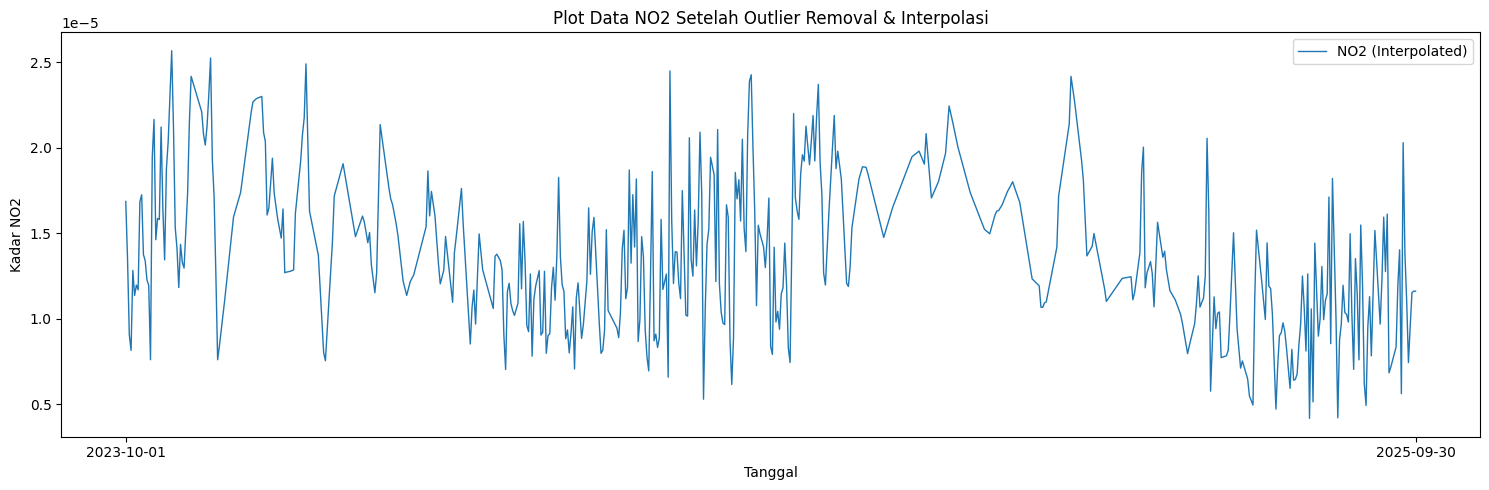

In [74]:
plt.figure(figsize=(15,5))
# Plot data hasil interpolasi
plt.plot(df['date'], df['NO2_filled'], label="NO2 (Interpolated)", linewidth=1)
# Tampilkan hanya tanggal awal dan akhir di sumbu X
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.title("Plot Data NO2 Setelah Outlier Removal & Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

Gambar X. Data $NO_2$ setelah proses penghapusan outlier dan pengisian kembali menggunakan Interpolasi Linear.

Berdasarkan hasil yang diperoleh, seluruh data outlier berhasil ditangani sehingga dataset menjadi lebih bersih dan siap digunakan pada tahap pemodelan KNN Regression.

# 3. Modeling Menggunakan KNN Regression

Pada tahap ini, data time series harian kadar NO₂ di Kabupaten Pamekasan digunakan untuk memprediksi kadar NO₂ pada satu hari berikutnya menggunakan metode K-Nearest Neighbor (KNN) Regression. Sebelum proses pemodelan dilakukan, data perlu diubah ke bentuk supervised learning agar dapat digunakan sebagai data latih dan data uji.

## a. Normalisasi Data

Sebelum melakukan proses pemodelan dan uji korelasi, data hasil preprocessing perlu dinormalisasi terlebih dahulu. Normalisasi dilakukan menggunakan metode Min-Max Scaling untuk mengubah rentang nilai data menjadi 0 sampai 1. Proses ini penting karena algoritma KNN Regression menggunakan perhitungan jarak antar data sehingga sensitif terhadap perbedaan skala nilai.

In [77]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scaler = MinMaxScaler()

df['NO2_scaled'] = scaler.fit_transform(df[['NO2']])

print(df.head())
print(df.columns)

        date       NO2  NO2_cleaned  NO2_filled  NO2_scaled
0 2023-10-01  0.000017     0.000017    0.000017    0.512550
1 2023-10-02  0.000014     0.000014    0.000014    0.376838
2 2023-10-03  0.000009     0.000009    0.000009    0.197546
3 2023-10-04  0.000008     0.000008    0.000008    0.160620
4 2023-10-05  0.000013     0.000013    0.000013    0.349482
Index(['date', 'NO2', 'NO2_cleaned', 'NO2_filled', 'NO2_scaled'], dtype='object')


Setelah proses normalisasi, terbentuk kolom baru bernama NO2_scaled yang berisi nilai kadar NO₂ dalam rentang 0–1 dan akan digunakan pada tahap pemodelan berikutnya.

## b. Uji Korelasi Data

Data time series pada awalnya merupakan data unsupervised, karena hanya terdiri dari satu variabel yaitu kadar NO₂ tanpa label. Oleh karena itu, data diubah terlebih dahulu menjadi bentuk supervised learning dengan memanfaatkan nilai NO₂ pada beberapa hari sebelumnya sebagai fitur (lag feature) dan nilai NO₂ pada hari ke-t sebagai target.

Pada tahap ini dibuat fitur dari 30 hari sebelumnya (t-30 sampai t-1) dan target hari ke-t untuk mengetahui hubungan antara nilai NO₂ pada masa lalu dengan nilai NO₂ saat ini.

In [81]:
import pandas as pd

def create_supervised(data, n_lag=4):
    df_supervised = pd.DataFrame()

    # Membuat fitur t-4 sampai t-1
    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)

    # Label hari H
    df_supervised['NO2(t)'] = data

    # Hapus baris yang masih mengandung NaN akibat shift
    df_supervised.dropna(inplace=True)

    return df_supervised

# contoh penggunaan
supervised_df30 = create_supervised(df['NO2_scaled'], n_lag=30)

# Ambil semua lag dan kolom target
lag_cols = supervised_df30.drop(columns="NO2(t)").columns
correlations = supervised_df30[lag_cols].corrwith(supervised_df30['NO2(t)'])

# Tampilkan nilai korelasi
print(correlations)

NO2(t-30)    0.387067
NO2(t-29)    0.370138
NO2(t-28)    0.385005
NO2(t-27)    0.401007
NO2(t-26)    0.367593
NO2(t-25)    0.359230
NO2(t-24)    0.376074
NO2(t-23)    0.385989
NO2(t-22)    0.359210
NO2(t-21)    0.360852
NO2(t-20)    0.342421
NO2(t-19)    0.305545
NO2(t-18)    0.269005
NO2(t-17)    0.279719
NO2(t-16)    0.302891
NO2(t-15)    0.281610
NO2(t-14)    0.286659
NO2(t-13)    0.269271
NO2(t-12)    0.265624
NO2(t-11)    0.299856
NO2(t-10)    0.327277
NO2(t-9)     0.330213
NO2(t-8)     0.353822
NO2(t-7)     0.410491
NO2(t-6)     0.455691
NO2(t-5)     0.493822
NO2(t-4)     0.552998
NO2(t-3)     0.608528
NO2(t-2)     0.676435
NO2(t-1)     0.791104
dtype: float64


Hasil pengujian menunjukkan bahwa nilai korelasi tertinggi diperoleh pada fitur yang memiliki jarak waktu paling dekat dengan target, yaitu $NO_2(t−1)$ hingga $NO_2(t−4)$. Keempat fitur tersebut memiliki nilai korelasi lebih dari 0,5, sehingga dapat dikategorikan memiliki hubungan yang cukup kuat terhadap nilai NO₂ pada hari ke-t dan dipilih sebagai fitur utama pada proses pemodelan.

## c. Mengubah Data Menjadi Bentuk Supervised Learning

Pada penelitian ini, data deret waktu (time series) diubah ke dalam bentuk `supervised learning` agar dapat digunakan sebagai masukan pada model KNN Regression. Sebelumnya, model hanya menggunakan 2 fitur historis.

Namun, berdasarkan hasil uji korelasi, nilai $NO_2$ `pada 4 hari sebelumnya (t-1 sampai t-4)` memiliki korelasi yang kuat terhadap nilai NO₂ saat ini, yaitu lebih dari 0,5. Oleh karena itu, digunakan 4 data historis sebagai fitur prediktor dan 1 data saat ini sebagai target (label).



In [82]:
supervised_df = create_supervised(df['NO2_scaled'], n_lag=4)

print(supervised_df)
print(supervised_df.shape)

     NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
4    0.512550  0.376838  0.197546  0.160620  0.349482
5    0.376838  0.197546  0.160620  0.349482  0.290269
6    0.197546  0.160620  0.349482  0.290269  0.314884
7    0.160620  0.349482  0.290269  0.314884  0.303732
8    0.349482  0.290269  0.314884  0.303732  0.512318
..        ...       ...       ...       ...       ...
726  0.058398  0.651408  0.389613  0.277290  0.131966
727  0.651408  0.389613  0.277290  0.131966  0.218042
728  0.389613  0.277290  0.131966  0.218042  0.297077
729  0.277290  0.131966  0.218042  0.297077  0.300530
730  0.131966  0.218042  0.297077  0.300530  0.300530

[727 rows x 5 columns]
(727, 5)


Hasil transformasi menghasilkan dataset dengan `727 baris` dan `5 kolom`, yang terdiri dari empat fitur historis (`NO2(t-4)` hingga `NO2(t-1)`) dan satu kolom target (`NO2(t)`). Dataset ini digunakan sebagai data masukan untuk proses pelatihan model.

Selanjutnya, dilakukan percobaan dengan menambah jumlah data historis menjadi `10 hari sebelumnya` untuk mengetahui apakah penggunaan fitur yang lebih banyak dapat meningkatkan performa prediksi model. Perubahan ini dilakukan dengan mengubah parameter `n_lag` menjadi 10.


In [83]:
supervised_df10 = create_supervised(df['NO2_scaled'], n_lag=10)

print(supervised_df10)
print(supervised_df10.shape)

     NO2(t-10)  NO2(t-9)  NO2(t-8)  NO2(t-7)  NO2(t-6)  NO2(t-5)  NO2(t-4)  \
10    0.512550  0.376838  0.197546  0.160620  0.349482  0.290269  0.314884   
11    0.376838  0.197546  0.160620  0.349482  0.290269  0.314884  0.303732   
12    0.197546  0.160620  0.349482  0.290269  0.314884  0.303732  0.512318   
13    0.160620  0.349482  0.290269  0.314884  0.303732  0.512318  0.528265   
14    0.349482  0.290269  0.314884  0.303732  0.512318  0.528265  0.387022   
..         ...       ...       ...       ...       ...       ...       ...   
726   0.120759  0.136686  0.152612  0.168538  0.312980  0.398272  0.058398   
727   0.136686  0.152612  0.168538  0.312980  0.398272  0.058398  0.651408   
728   0.152612  0.168538  0.312980  0.398272  0.058398  0.651408  0.389613   
729   0.168538  0.312980  0.398272  0.058398  0.651408  0.389613  0.277290   
730   0.312980  0.398272  0.058398  0.651408  0.389613  0.277290  0.131966   

     NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)  
10   0.303732  0.

Hasilnya, dataset memiliki `721 baris` dan `11 kolom`, yang terdiri dari sepuluh fitur historis (`NO2(t-10)` hingga `NO2(t-1)`) dan satu kolom target (`NO2(t)`). Perbedaan jumlah baris terjadi karena semakin besar nilai *lag*, semakin banyak data awal yang tidak dapat digunakan. Dataset dengan *lag* 4 dan *lag* 10 kemudian dibandingkan untuk mengetahui jumlah fitur historis yang memberikan hasil prediksi terbaik pada model KNN Regression.

## d. Modeling dan Evaluasi

Setelah data diubah ke bentuk supervised learning, tahap berikutnya adalah melakukan pelatihan model menggunakan KNN Regression. Pada penelitian ini digunakan `KNeighborsRegressor` dengan nilai `n_neighbors = 5`. Data kemudian dibagi menjadi data latih dan data uji dengan rasio 80:20 tanpa melakukan *shuffle* agar urutan data deret waktu tetap terjaga.

Untuk mengevaluasi performa model, digunakan beberapa metrik yaitu RMSE (Root Mean Squared Error), $R^² Score$, dan $MAPE$ (Mean Absolute Percentage Error).


In [84]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Hindari pembagian dengan nol
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def train_knn(df_supervised, model_name=""):
    # Pisahkan fitur & label
    X = df_supervised.drop(columns=['NO2(t)']).values
    y = df_supervised['NO2(t)'].values

    # Split data 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    # Model KNN
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)

    # Prediksi
    y_pred = knn.predict(X_test)

    # Evaluasi
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Train Size: {len(X_train)} — Test Size: {len(X_test)}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.4f}%")

    return knn, y_test, y_pred


# Train model untuk 4 hari sebelumnya
knn_4, y_test_4, y_pred_4 = train_knn(supervised_df, "KNN - 4 Hari Sebelumnya")

# Train model untuk 10 hari sebelumnya
knn_10, y_test_10, y_pred_10 = train_knn(supervised_df10, "KNN - 10 Hari Sebelumnya")


=== KNN - 4 Hari Sebelumnya ===
Train Size: 581 — Test Size: 146
RMSE: 0.140726
R² Score: -0.2571
MAPE: 234.1486%

=== KNN - 10 Hari Sebelumnya ===
Train Size: 576 — Test Size: 145
RMSE: 0.145435
R² Score: -0.3539
MAPE: 196.6922%


Model pertama dilatih menggunakan data dengan `4 hari sebelumnya (lag = 4)`, sedangkan model kedua menggunakan `10 hari sebelumnya (lag = 10)`.

Hasil evaluasi menunjukkan bahwa model dengan `10 hari sebelumnya` menghasilkan nilai `MAPE yang lebih rendah` dibandingkan model dengan `4 hari sebelumnya` (196,69% dibandingkan 234,15%).

Hasil evaluasi menunjukkan bahwa model dengan 10 hari sebelumnya menghasilkan nilai MAPE yang lebih rendah dibandingkan model dengan 4 hari sebelumnya, yaitu 196,69% dibandingkan 234,15%. Namun, nilai RMSE meningkat dari 0,140726 menjadi 0,145435 dan nilai R² menurun dari -0,2571 menjadi -0,3539. Hal ini menunjukkan bahwa penambahan jumlah data historis belum memberikan peningkatan performa yang konsisten pada seluruh metrik evaluasi. Meskipun demikian, penurunan nilai MAPE menunjukkan bahwa kesalahan prediksi secara persentase relatif lebih kecil dibandingkan model dengan 4 hari sebelumnya.

Untuk menguji lebih lanjut pengaruh jumlah data historis, dilakukan percobaan menggunakan `30 hari sebelumnya (lag = 30)`.



In [85]:
knn_30, y_test_30, y_pred_30 = train_knn(supervised_df30, "KNN - 30 Hari Sebelumnya")


=== KNN - 30 Hari Sebelumnya ===
Train Size: 560 — Test Size: 141
RMSE: 0.151286
R² Score: -0.4745
MAPE: 317.1345%


Dibandingkan dengan model sebelumnya, penggunaan `30 hari historis (lag = 30)` menghasilkan nilai `RMSE sebesar 0,151286` dan `MAPE sebesar 317,1345%`, yang lebih tinggi dibandingkan model dengan *lag* 4 maupun *lag* 10. Selain itu, nilai `R² Score sebesar -0,4745` menunjukkan bahwa kemampuan model dalam menjelaskan variasi data masih rendah dan bahkan lebih buruk dibandingkan kedua model sebelumnya. Hasil ini menunjukkan bahwa penambahan jumlah data historis tidak selalu meningkatkan performa model. Terlalu banyak fitur dapat menambah kompleksitas data sehingga model KNN kesulitan menemukan tetangga yang benar-benar mirip. Berdasarkan hasil pengujian, model dengan `10 hari sebelumnya (lag = 10)` memberikan performa yang lebih baik dibandingkan penggunaan 4 hari maupun 30 hari sebelumnya karena menghasilkan nilai MAPE yang paling rendah.

## e. Plotting

Plotting dilakukan untuk memvisualisasikan perbandingan antara nilai aktual (*actual*) dan nilai hasil prediksi (*predicted*) dari model KNN Regression. Visualisasi ini digunakan untuk melihat sejauh mana model mampu mengikuti pola data aktual pada setiap skenario jumlah fitur historis (*lag*).

### 4 Hari Sebelumnya

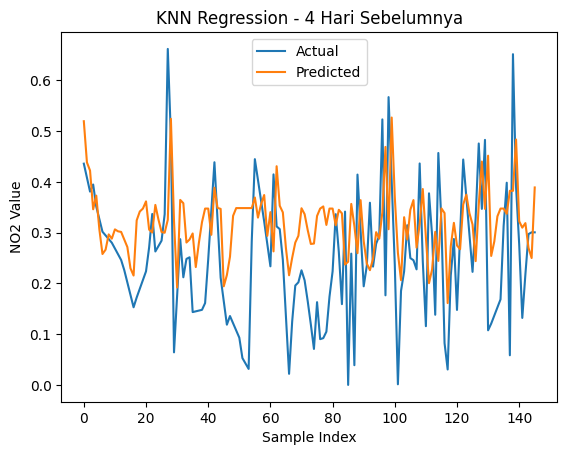

In [86]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(np.arange(len(y_test_4)), y_test_4, label="Actual")
plt.plot(np.arange(len(y_pred_4)), y_pred_4, label="Predicted")
plt.title("KNN Regression - 4 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

### 10 Hari Sebelumnya

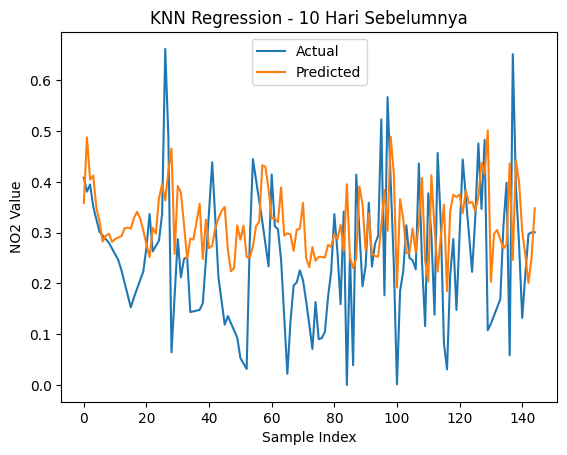

In [87]:
plt.figure()
plt.plot(np.arange(len(y_test_10)), y_test_10, label="Actual")
plt.plot(np.arange(len(y_pred_10)), y_pred_10, label="Predicted")
plt.title("KNN Regression - 10 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

In [88]:
print(supervised_df30.shape)

(701, 31)


In [89]:
knn_30, y_test_30, y_pred_30 = train_knn(
    supervised_df30,
    "KNN - 30 Hari Sebelumnya"
)


=== KNN - 30 Hari Sebelumnya ===
Train Size: 560 — Test Size: 141
RMSE: 0.151286
R² Score: -0.4745
MAPE: 317.1345%


### 30 Hari Sebelumnya

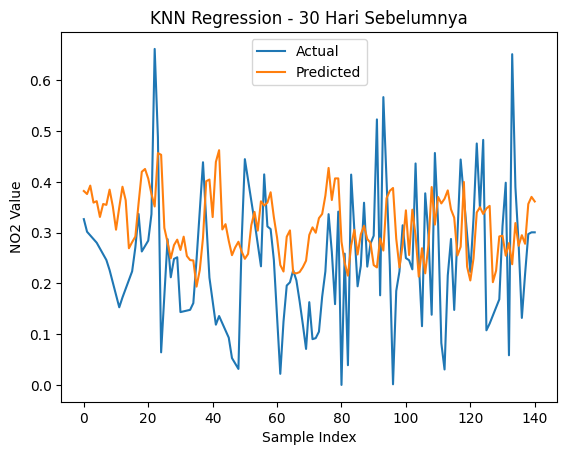

In [90]:
plt.figure()
plt.plot(np.arange(len(y_test_30)), y_test_30, label="Actual")
plt.plot(np.arange(len(y_pred_30)), y_pred_30, label="Predicted")
plt.title("KNN Regression - 30 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

Berdasarkan hasil visualisasi, terlihat bahwa garis prediksi pada ketiga model cenderung mengikuti pola umum data aktual, namun belum mampu menangkap fluktuasi data secara akurat. Hal ini terlihat dari beberapa titik ketika nilai aktual mengalami kenaikan atau penurunan yang cukup tajam, sedangkan nilai prediksi cenderung bergerak lebih stabil dan tidak sepenuhnya mengikuti perubahan tersebut.

Pada model dengan `4 hari sebelumnya (lag = 4)`, garis prediksi masih menunjukkan perbedaan yang cukup besar terhadap nilai aktual, terutama pada titik-titik yang mengalami perubahan ekstrem. Pada model `10 hari sebelumnya (lag = 10)`, pola prediksi terlihat sedikit lebih mendekati data aktual dibandingkan model sebelumnya, meskipun masih terdapat selisih pada beberapa titik pengamatan.

Sementara itu, pada model `30 hari sebelumnya (lag = 30)`, garis prediksi terlihat semakin halus dan cenderung berada di sekitar nilai rata-rata data. Akibatnya, model kurang mampu mengikuti fluktuasi nilai aktual yang berubah secara tajam. Hal ini menunjukkan bahwa penambahan jumlah fitur historis yang terlalu banyak tidak selalu meningkatkan kemampuan model dalam melakukan prediksi.

Hasil visualisasi ini sejalan dengan hasil evaluasi yang diperoleh sebelumnya. Model dengan `10 hari sebelumnya (lag = 10)` menghasilkan nilai MAPE yang lebih rendah dibandingkan model dengan 4 hari dan 30 hari sebelumnya, sehingga memberikan performa yang relatif lebih baik. Namun, nilai MAPE yang masih tinggi serta nilai R² yang negatif pada seluruh skenario menunjukkan bahwa model KNN Regression masih belum mampu memprediksi data NO₂ dengan tingkat akurasi yang optimal. Oleh karena itu, diperlukan pengembangan lebih lanjut, seperti optimasi parameter KNN atau penggunaan metode prediksi lain untuk memperoleh hasil yang lebih baik.